# 2. Parameter recovery

> **Level** Beginner · **Time** 20 minutes · **Prerequisites** [1. Build and fit your first model](first-model.ipynb) ·
> **cpm components** [`Parameters.sample`](#cpm.generators.Parameters.sample), [`Simulator`](#cpm.generators.Simulator), [`LogLikelihood`](#cpm.optimisation.minimise.LogLikelihood), [`FminBound`](#cpm.optimisation.FminBound) ·
> **Data** [`load_bandit_data`](#cpm.datasets.load_bandit_data)

Before we interpret the parameters we estimate from data, we should check that the model and the fitting procedure can recover them at all.
In a parameter recovery study, we simulate data from known parameters, fit the model to the simulated data, and compare the estimates with the parameters we started from (Wilson & Collins, 2019).
If the estimates do not match the true parameters for simulated data, they will not be meaningful for real data either.

**What you'll learn**

- how to sample parameters from their priors,
- how to simulate choices from a model with a [`Simulator`](#cpm.generators.Simulator),
- how the likelihood of choices is computed when fitting,
- how to judge whether parameters are recoverable.

In [1]:
import cpm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(cpm.__version__)
np.random.seed(2026)

0.25.7.dev0


## The model

We use the reinforcement learning model of [Tutorial 1](first-model.ipynb): a delta rule with a learning rate $\alpha$, and a Softmax choice rule with an inverse temperature $\beta$.
With `generate=True`, the model makes its own choices and learns from them; with `generate=False`, it learns from the choices in the data.

In [2]:
from cpm.datasets import load_bandit_data
from cpm.generators import Parameters, Value, Wrapper
from cpm.models.decision import Softmax
from cpm.models.learning import SeparableRule

data = load_bandit_data()
data["observed"] = data["response"]  # replaced by the simulated choices below

parameters = Parameters(
    alpha=Value(value=0.5, lower=1e-10, upper=1, prior="truncated_normal", args={"mean": 0.5, "sd": 0.25}),
    temperature=Value(value=1, lower=0, upper=10, prior="truncated_normal", args={"mean": 5, "sd": 2.5}),
    values=np.array([0.25, 0.25, 0.25, 0.25]),
)


def model(parameters, trial, generate=False):
    values = np.asarray(parameters.values).copy()
    stimuli = np.array([trial.arm_left, trial.arm_right]).astype(int)
    rewards = np.array([trial.reward_left, trial.reward_right])

    choice_rule = Softmax(activations=values[stimuli - 1], temperature=parameters.temperature)
    choice_rule.compute()
    choice = choice_rule.choice() if generate else int(trial.response)
    reward = rewards[choice]

    chosen = np.zeros(4)
    chosen[stimuli[choice] - 1] = 1
    update = SeparableRule(weights=values, feedback=[reward], input=chosen, alpha=parameters.alpha)
    update.compute()
    values += update.weights.flatten()

    return {
        "policy": choice_rule.policies,
        "response": choice,
        "reward": reward,
        "values": values,
        "dependent": np.array([choice_rule.policies[1]]),
    }

## Step 1: sample the true parameters

We draw one set of parameters for each of the 200 participants from the priors of the parameters, with [`Parameters.sample`](#cpm.generators.Parameters.sample).
These are the true parameters that we will try to recover.

In [3]:
number_of_participants = data.ppt.nunique()
true_parameters = pd.DataFrame(parameters.sample(size=number_of_participants))
true_parameters.describe()

,alpha,temperature
count,200.000000,200.000000
mean,0.494487,5.158831
std,0.229418,2.163145
min,0.010172,0.104568
25%,0.327023,3.562171
50%,0.490639,5.158901
75%,0.653261,6.673379
max,0.988997,9.992580


## Step 2: simulate choices

The [`Simulator`](#cpm.generators.Simulator) runs the generative version of the model for every participant, each with their own true parameters.
We use the trial sequence of the real participants, so the simulated agents see the same stimuli and could earn the same rewards.

In [4]:
from functools import partial

from cpm.generators import Simulator

generative_model = Wrapper(
    model=partial(model, generate=True),
    parameters=parameters,
    data=data[data.ppt == 1],
)
simulator = Simulator(
    wrapper=generative_model,
    data=data.groupby("ppt"),
    parameters=true_parameters,
)
simulator.run()
simulated = simulator.export()
simulated[["ppt", "response", "reward", "policy_0", "policy_1"]].head()

,ppt,response,reward,policy_0,policy_1
0,1,1,1.0,0.500000,0.500000
1,1,1,0.0,0.500000,0.500000
2,1,1,0.0,0.743497,0.256503
3,1,1,0.0,0.805176,0.194824
4,1,1,0.0,0.412233,0.587767


We replace the choices of the participants with the simulated choices.
The fitting model learns from `response`, and is fitted to `observed`, so both columns hold the simulated choices.

In [5]:
recovery_data = data.copy()
recovery_data["response"] = simulated["response"].to_numpy()
recovery_data["observed"] = simulated["response"].to_numpy()
recovery_data.head()

,ppt,trial,arm_left,arm_right,reward_left,reward_right,response,feedback,observed
0,1,1,2,1,0.0,1.0,1,1.0,1
1,1,2,3,2,1.0,0.0,1,1.0,1
2,1,3,1,3,1.0,0.0,1,1.0,1
3,1,4,1,3,0.0,0.0,1,0.0,1
4,1,5,2,4,1.0,0.0,1,1.0,1


## Step 3: fit the model to the simulated choices

To fit the model, we find the parameters $\theta$ that minimise the negative log-likelihood of the choices $Y$ of each participant:

$$
-\log L(\theta \mid Y) = -\sum_{t=1}^{N} \log p(y_t \mid \theta)
$$

where $N$ is the number of trials.
Each choice is binary, so its probability follows a Bernoulli distribution, where $P(a_t)$ is the probability that the model gives to choosing the stimulus on the right:

$$
p(y_t \mid \theta) =
\begin{cases}
P(a_t) & \text{if } y_t = 1, \\
1 - P(a_t) & \text{if } y_t = 0.
\end{cases}
$$

This loss is implemented as [`LogLikelihood.bernoulli`](#cpm.optimisation.minimise.LogLikelihood.bernoulli), so it does not have to be part of the model.
For tasks with more than two options, [`LogLikelihood.categorical`](#cpm.optimisation.minimise.LogLikelihood.categorical) works with the same model.
We fit without priors (`prior=False`), so the estimates are maximum-likelihood estimates, which are not pulled towards the prior.

In [6]:
from cpm.optimisation import FminBound, minimise

fitting_model = Wrapper(model=model, parameters=parameters, data=recovery_data[recovery_data.ppt == 1])
fit = FminBound(
    model=fitting_model,
    data=recovery_data.groupby("ppt"),
    minimisation=minimise.LogLikelihood.bernoulli,
    prior=False,
    number_of_starts=3,
    ppt_identifier="ppt",
    parallel=False,
    display=False,
    approx_grad=True,
)
fit.optimise()
recovered_parameters = pd.DataFrame(fit.parameters)

## Step 4: compare the estimates with the true parameters

If the parameters are recoverable, the estimates lie close to the identity line, and the correlation between the true and the recovered parameters is high.

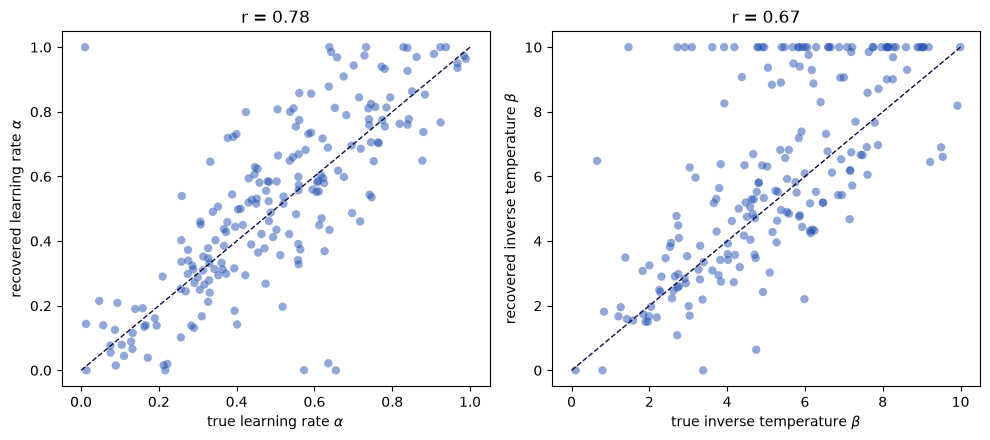

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
labels = {"alpha": r"learning rate $\alpha$", "temperature": r"inverse temperature $\beta$"}
for ax, name in zip(axes, labels):
    true, recovered = true_parameters[name], recovered_parameters[name]
    r = np.corrcoef(true, recovered)[0, 1]
    ax.scatter(true, recovered, alpha=0.5, color="#2350b0", edgecolor="none")
    limits = [min(true.min(), recovered.min()), max(true.max(), recovered.max())]
    ax.plot(limits, limits, color="#0c0c45", linestyle="--", linewidth=1)
    ax.set_xlabel(f"true {labels[name]}")
    ax.set_ylabel(f"recovered {labels[name]}")
    ax.set_title(f"r = {r:.2f}")
plt.tight_layout()
plt.show()

In [8]:
comparison = pd.DataFrame(
    {
        name: {
            "correlation": np.corrcoef(true_parameters[name], recovered_parameters[name])[0, 1],
            "mean absolute error": np.mean(np.abs(true_parameters[name] - recovered_parameters[name])),
        }
        for name in ["alpha", "temperature"]
    }
)
comparison.round(2)

,alpha,temperature
correlation,0.78,0.67
mean absolute error,0.12,1.73


The learning rate is recovered well: most estimates lie close to the identity line.
The inverse temperature is recovered less well, and the plot shows why: many estimates end up at the upper bound of 10, even when the true value is much lower.
With only 72 trials, an agent that happens to make few choices against its values looks almost deterministic, and maximum likelihood then pushes the inverse temperature to its bound.

Things to try:

- Increase the number of trials, by simulating each participant twice, and see how recovery changes.
- Fit with `prior=True`. The estimates will be pulled towards the mean of the prior: better for noisy participants, but biased.
- Narrow the prior of the inverse temperature, and see whether the learning rate becomes easier to recover.

## Summary and next steps

You simulated choices from known parameters, refitted the model, and compared the estimates with the true parameters.
Parameter recovery tells you how much you can trust the estimates of a model for a given task design and number of trials.
It does not tell you whether the model is the right one: for that, we need to compare models, which is the topic of [3. Model recovery and model comparison](model-recovery.ipynb).

## References

Wilson, R. C., & Collins, A. G. E. (2019). Ten simple rules for the computational modeling of behavioral data. *eLife*, 8, e49547. https://doi.org/10.7554/eLife.49547